# Calibration for Binary Classification
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/yggdrasil-decision-forests/blob/main/documentation/public/docs/tutorial/binary_calibration.ipynb)


## Setup

In [ ]:
pip install ydf -U

## Why Calibrate?

After training a binary classification model (e.g., predicting whether an email is `SPAM` or `NOT_SPAM`), the predicted probabilities are often not representative of the actual observed rates of the positive label.
For example, a binary classifier might output a predicted probability of 30%, but the true rate of observing the `SPAM` label at that predicted rate could be 45% or just 22% (i.e. _not_ 30%).
Correcting this mismatch is referred to as calibration.

### When should you care?

You should consider calibrating your binary classification model if your workflow meets any of the following conditions:

* **You use predicted probabilities as direct decision thresholds:** If you trigger down-stream actions based on a specific probability (e.g., *"If spam probability > 85%, auto-delete the email"*), you need those numbers to reflect true historical frequencies.
* **Your outputs feed into expected value calculations:** If your model's probability $p$ is used to calculate risk or financial outcomes (e.g., $\mathrm{Expected Value}=p\times\mathrm{Value}$), uncalibrated probabilities will severely bias your financial projections and lead to poor resource allocation.
* **You are combining or comparing multiple models:** If you have multiple models feeding into a single decision engine, they must speak the "same language." Uncalibrated models cannot have their probabilities compared or combined reliably.
* **You are using models prone to overconfidence:** Heavy modern classifiers (like deep trees or deep learning architectures) are notorious for pushing predictions close to `0.0` or `1.0` without actual statistical justification.

Note:
> Calibration will not improve your model's ranking metrics (like ROC-AUC) because YDF uses isotonic regression, which strictly preserves prediction ordering.
> If your only goal is to rank items (e.g., recommendation feeds), calibration is likely unnecessary overhead.

This tutorial walks through how to calibrate a binary classifier in YDF as well as how you assess calibration information included in the evaluation results.


## Binary classification model

For calibration, let's start by training a binary classification model on a real dataset.
We'll use the classic "Adult" dataset for this tutorial.

In [ ]:
# Load necessary libraries
import ydf          # Yggdrasil Decision Forests.
import pandas as pd # To load and inspect the dataset.

# Download a classification dataset and load it as a Pandas DataFrame.
ds_path = "https://raw.githubusercontent.com/google/yggdrasil-decision-forests/main/yggdrasil_decision_forests/test_data/dataset"
train_ds = pd.read_csv(f"{ds_path}/adult_train.csv")
test_ds = pd.read_csv(f"{ds_path}/adult_test.csv")

The data is already partitioned into train and test splits.
However, when calibrating a model it is advised that you reserve an additional held-out portion of data specifically for this purpose.

In [ ]:
# We will reserve 10% of the training data for calibration.
cal_ds = train_ds.sample(frac = 0.10, random_state=0)
train_ds = train_ds.drop(cal_ds.index)

The task is binary classification: predict whether an individual's income is `>50k` or `<=50k` based on other numerical and categorical features.
This dataset also contains missing values, which YDF handles automatically.

In [ ]:
# Note: task=ydf.Task.CLASSIFICATION is the default, so it's optional here.
model = ydf.RandomForestLearner(label="income").train(train_ds)

Train model on 20513 examples
Model trained in 0:00:02.491828


The evaluation plots for a binary classification model include a [reliability diagram](https://scikit-learn.org/stable/modules/calibration.html#calibration-curves).
This diagram reveals how well the predicted probabilities reflect the frequency of the true label.
Ideally, this curve is a $45^\circ$ line between $(0,0)$ and $(1,1)$.
The error band around the curve is proportional to the amount of data used to determine the reliability at that point (specifically, a Beta-binomial error model).

Two calibration-related metrics are also included: the MCE and ECE.
These two metrics summarize how well the actual curve matches the ideal.

In [ ]:
evaluation = model.evaluate(test_ds)
evaluation

Label \ Pred,<=50K,>50K
<=50K,6964,448
>50K,888,1469


How well the model is calibrated can be assessed from the Expected Calibration Error (ECE), Maximum Calibration Error (MCE), and the Reliability Diagram.
Detailed descriptions of each of these are given in the provided glossary.
Note that from the Reliability Diagram we can see that the model is poorly calibrated.
This is evident in the fact the curve is significantly different from the ideal (below).

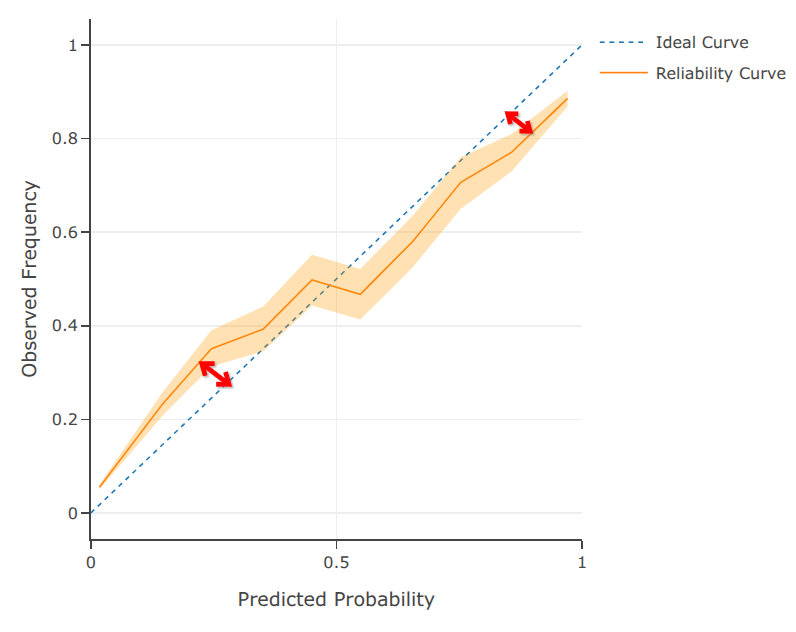

Let's run YDF's calibration routine to modify the model's prediction such that they better match the observed frequencies in the data.

## Calibrate

A model has a `calibrate` method that accepts a dataset who's labels the model's predictions are calibrated.
The method also requires a `ydf.CalibrationConfig`.
There are two hyperparameters used to perform the calibration and another hyperparameter for deployment.
Here we will set a parameter that controls the amount of smoothing (`z_threshold`) as this results in the best fit.

Here we'll calibrate on specially reserved dataset that is 10% of the original dataset.

In [ ]:
# Calibrate the model in place.
model.calibrate(
    cal_ds,
    config=ydf.CalibrationConfig(z_threshold=1.0),
)

Let's re-evaluate on the test set to see if the reliability diagram has improved.

In [ ]:
evaluation = model.evaluate(test_ds)
evaluation

Label \ Pred,<=50K,>50K
<=50K,7001,411
>50K,912,1445


Both the metrics and reliability diagram show substantial improvements while leaving the quality metrics unchanged.
The calibration hyperparameters are detailed [here](https://ydf.readthedocs.io/en/latest/py_api/GenericModel/#ydf.GenericModel.calibrate) and you may need to tune them to your use case.

### Technical Note

Normal isotonic regression fitting for calibration will perfectly align the data used for calibration with the ideal reliability diagram (i.e. the $45^\circ$ diagonal).
However, the method used in YDF uses isotonic regression as a starting point for further smoothing and interpolation.
Thus, the performance of the calibration on the data used for calibration will _not_ be perfectly calibrated.
See [here](https://ydf.readthedocs.io/en/latest/tutorial/pav_calibration_theory/) for a detailed explanation for why this behavior is expected.

In [ ]:
evaluation = model.evaluate(cal_ds)
evaluation

Label \ Pred,<=50K,>50K
<=50K,1617,104
>50K,220,338


Notice that the reliability diagram is near the ideal, but clearly diverges especially in the reliability diagram's lowest-populated bins.
Performance on other datasets may have an even larger divergence.
Again, tune the calibration parameters until you attain a reliability diagram and set of metrics suitable for your application.